# Class task


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score



In [ ]:
titanic_df = pd.read_csv("titanic.csv")

In [ ]:
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
titanic_df = titanic_df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])


In [ ]:
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
titanic_df = titanic_df.drop(columns = ["SibSp", "Parch"])

In [ ]:
titanic_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S


In [ ]:
df = pd.DataFrame(titanic_df)

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())


In [ ]:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})


In [ ]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked
0,0,3,0,22.0,7.2500,S
1,1,1,1,38.0,71.2833,C
2,1,3,1,26.0,7.9250,S
3,1,1,1,35.0,53.1000,S
4,0,3,0,35.0,8.0500,S


In [ ]:
x = df[["Age", 'Pclass','Fare', 'Sex' ]].to_numpy()
y = df["Survived"].to_numpy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


NameError: name 'X' is not defined

In [ ]:
linear_reg = LinearRegression()
linear_reg.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.4551
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[388.41]


In [ ]:
y_pred = linear_reg.predict(X_test)


In [ ]:
y_pred

array([0.38714149, 0.37986369, 0.40654896, 0.44051203, 0.42110456,
       0.39199336, 0.38714149, 0.4162527 , 0.4162527 , 0.4089749 ,
       0.36530809, 0.34832655, 0.38714149, 0.38228963, 0.36773402,
       0.4162527 , 0.35317842, 0.38714149, 0.38956743, 0.34104875,
       0.39684523, 0.37258589, 0.4089749 , 0.40654896, 0.38714149,
       0.4308083 , 0.35803029, 0.37986369, 0.4453639 , 0.37986369,
       0.4089749 , 0.40169709, 0.38714149, 0.38714149, 0.41140083,
       0.38956743, 0.38714149, 0.38714149, 0.38228963, 0.38714149,
       0.40412303, 0.38471556, 0.38714149, 0.38714149, 0.34590062,
       0.4162527 , 0.4089749 , 0.39927116, 0.39684523, 0.31436348,
       0.44293797, 0.32891908, 0.35803029, 0.42838237, 0.29738195,
       0.41140083, 0.37743776, 0.33377095, 0.37015996, 0.4089749 ,
       0.40412303, 0.4235305 , 0.38714149, 0.38714149, 0.38714149,
       0.31678942, 0.40412303, 0.38471556, 0.41382676, 0.32891908,
       0.39199336, 0.41140083, 0.39199336, 0.36045622, 0.39927

In [ ]:
SSE = np.sum(np.power((y_test - y_pred),2))


In [ ]:
r2_score(y_test, y_pred)

0.008903247242629364

/tmp/ipykernel_21066/976795801.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


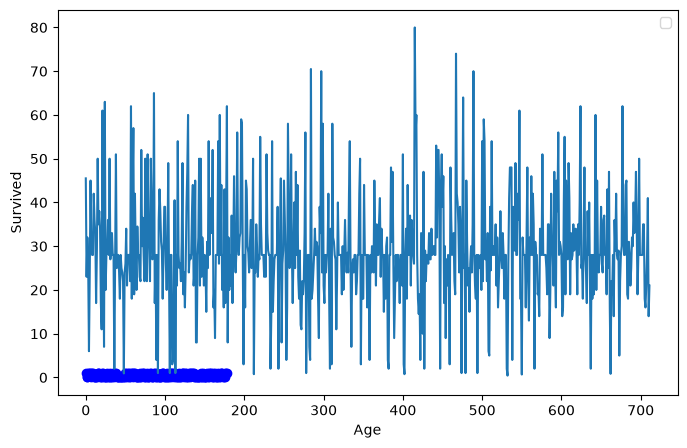

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(range(len(y_test)), y_test, color='blue' )
plt.plot(X_train )
plt.xlabel('Age')
plt.ylabel('Survived')
plt.legend()
plt.show()

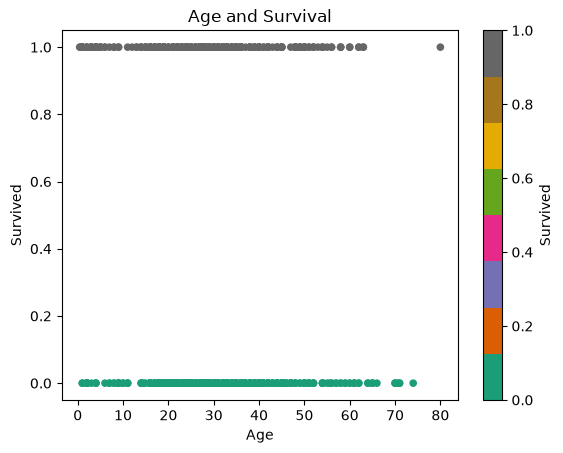

In [ ]:
df.plot.scatter(x='Age', y='Survived', c='Survived', cmap='Dark2')
plt.title("Age and Survival")
plt.xlabel("Age")
plt.ylabel("Survived")
plt.show()

In [ ]:
y_pred = linear_reg.predict(X_test)
print("Accurracy scores:", accuracy_score(y_test, y_pred))
print("classification report:\n", classification_report(y_test, y_pred))

NameError: name 'linear_reg' is not defined